# Block-diagonal sensitivity & conflicting-truth structural error

Two new data-generation features:

1. **Block-diagonal sensitivity structure** (`structure="blocks"` on `generate_linear_dataset` /
   `generate_exponential_dataset`): partition params into groups and outputs into groups, so
   param-group *g* exclusively (or near-exclusively) drives output-group *g*. A generalization of
   the existing `diag` (sliding window) structure to arbitrary, disjoint group sizes on both axes.
2. **Conflicting-truth structural error** (`generate_conflicting_truth_dataset`): multiple models
   (potentially different families -- linear, exponential, polynomial, ...) sharing the same
   parameter space, each contributing its own block of outputs over a *shared* training ensemble --
   but each model's "true" observation comes from its own independently-sampled true input. No
   single input reproduces every model's observation at once, which is what genuine structural
   error (model-form disagreement) looks like as data.

In [3]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np

from data_generator_funs.dataset import (
    generate_linear_dataset,
    generate_exponential_dataset,
    generate_conflicting_truth_dataset,
)
from utils.plotting import (
    plot_block_structure,
    plot_conflicting_truth,
    plot_data_overview,
    plot_correlation,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Block-diagonal sensitivity structure

`param_group_sizes=[2, 2, 2]`, `output_group_sizes=[3, 3, 4]` means: params 0-1 drive outputs 0-2,
params 2-3 drive outputs 3-5, params 4-5 drive outputs 6-9 -- and nothing else, unless
`background_scale > 0` adds a bit of cross-block coupling.

In [73]:
blocks_ds = generate_linear_dataset(
    n_samples=400, n_params=6, n_outputs=10,
    structure="blocks",
    structure_kwargs=dict(
        param_group_sizes=[2, 2, 2],
        output_group_sizes=[3, 3, 4],
        sensitivity_multiplier=3.0,
        background_scale=0.05,   # small cross-block leakage; try 0.0 for exact block-diagonal
    ),
    noise_std=0.1, structural_idx=[0], structural_error_level=0.3,
    seed=1,
)
print("param_group_id: ", blocks_ds["param_group_id"])
print("output_group_id:", blocks_ds["output_group_id"])

param_group_id:  [0 0 1 1 2 2]
output_group_id: [0 0 0 1 1 1 2 2 2 2]


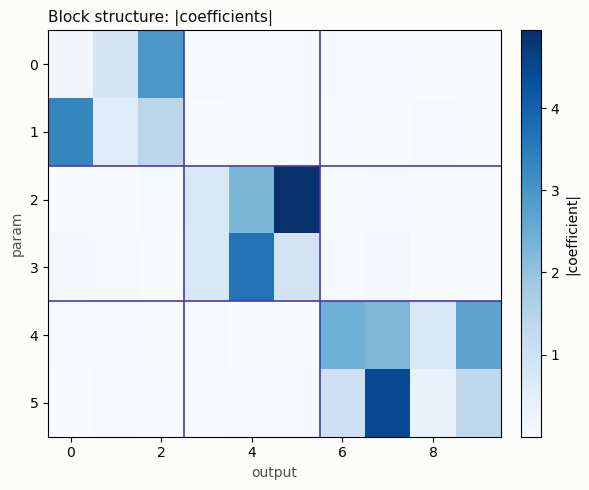

In [74]:
_ = plot_block_structure(blocks_ds)

The heatmap should show three visibly brighter squares along the block-diagonal (one per group),
with everything off it near-zero (just the `background_scale=0.05` leakage). Compare to the
correlation view and the per-output nonlinearity/interaction summary, which still work unchanged on
a `"blocks"` dataset -- they only look at X/Y shapes, not at `structure`.

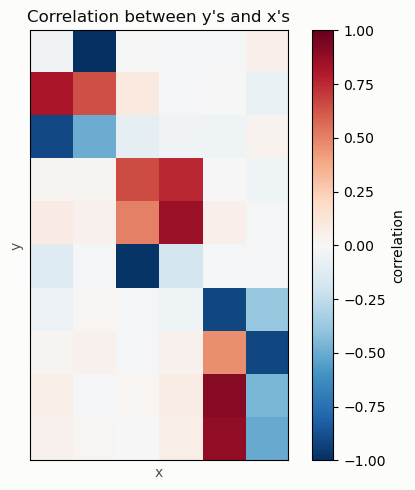

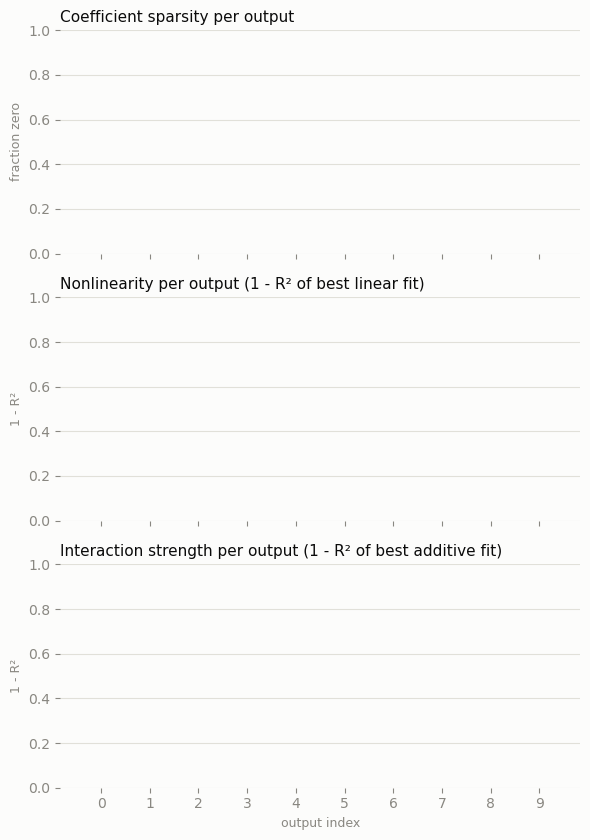

In [75]:
_ = plot_correlation(blocks_ds["X"], blocks_ds["Y"])
_ = plot_data_overview(blocks_ds)


The same structure works for `generate_exponential_dataset` -- same `param_group_sizes` /
`output_group_sizes` / `sensitivity_multiplier` / `background_scale` kwargs, plus the family's own
`scale` knob.

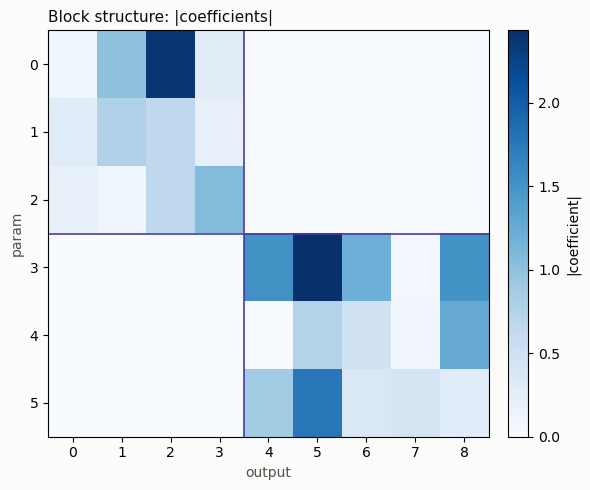

In [76]:
blocks_exp_ds = generate_exponential_dataset(
    n_samples=300, n_params=6, n_outputs=9,
    structure="blocks",
    structure_kwargs=dict(param_group_sizes=[3, 3], output_group_sizes=[4, 5], sensitivity_multiplier=2.0),
    seed=2,
)
_ = plot_block_structure(blocks_exp_ds)

### 1b. Overlapping parameter groups

`generate_matrix_blocks` requires a strict partition of params -- each param drives exactly one
output group. `structure="overlapping_blocks"` relaxes that: instead of `param_group_sizes`, give
`param_groups` as an explicit list of parameter-index lists, one per output group, which don't have
to be disjoint. E.g. `param_groups=[[0, 1], [1, 2]]`, `output_group_sizes=[4, 6]` means params 0-1
(x1, x2) drive outputs 0-3 (y1-y4) and params 1-2 (x2, x3) drive outputs 4-9 (y5-y10) -- param 1
(x2) is shared, driving both blocks.

param_group_membership (rows=params, cols=groups):
[[1 0 1]
 [1 1 1]
 [1 1 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]]
output_group_id: [0 0 0 0 1 1 1 1 1 1 2 2 2 2 2]



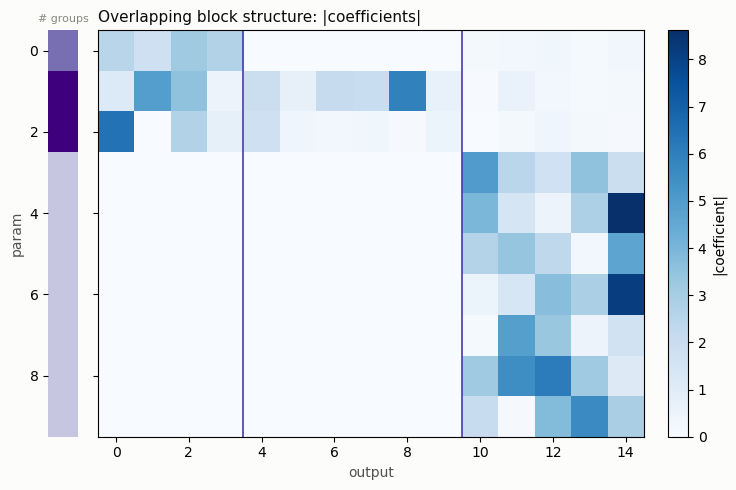

In [22]:
overlap_ds = generate_linear_dataset(
    n_samples=300, n_params=10, n_outputs=15,
    structure="overlapping_blocks",
    structure_kwargs=dict(
        param_groups=[[0, 1,2], [1, 2], list(range(3,10))],       # x1,x2 -> group 0 ; x2,x3 -> group 1 (x2 shared)
        output_group_sizes=[4, 6, 5],            # group 0 -> y1-y4 ; group 1 -> y5-y10
        sensitivity_multiplier=3.0,
        background_scale=0.0,      # exact zero off-block -> rows 3-9, cols 0-9 stay empty
        extra_links=[(0, -1)],     # group 0's params (rows 0-2) also get real coefficients in the last group's columns (10-19)
        shared_scale=0.5,
    ),
    seed=1,
)
print("param_group_membership (rows=params, cols=groups):")
print(overlap_ds["param_group_membership"])
print("output_group_id:", overlap_ds["output_group_id"])
print()

from utils.plotting import plot_overlapping_block_structure
_ = plot_overlapping_block_structure(overlap_ds)

In [28]:
overlap_ds['x_true'] @ overlap_ds['coefficients']['coefficients'] - overlap_ds['y_true']

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

## 2. Conflicting-truth structural error

Two models sharing the same 6-dimensional parameter space -- both linear, so we can isolate what
`generate_conflicting_truth_dataset` actually does from any effect of mixing model families --
each contributing its own block of outputs over one shared training ensemble `X`. Training data is
perfectly internally consistent (every row's `Y` blocks come from the same `x` row). The conflict
only shows up at calibration time: each model's `y_true` was generated from its own
independently-sampled true input, so no single input satisfies both blocks' observations.

In [29]:
model_specs = [
    {"name": "linear_1", "family": "linear", "n_outputs": 5,
     "structure": "full", "structure_kwargs": dict(n_sensitive_para=2, n_sensitive_output=3, sensitivity_multiplier=3.0)},
    {"name": "linear_2", "family": "linear", "n_outputs": 5,
     "structure": "full", "structure_kwargs": dict(n_sensitive_para=2, n_sensitive_output=3, sensitivity_multiplier=3.0)},
]

conflict_ds = generate_conflicting_truth_dataset(
    n_samples=400, n_params=6, model_specs=model_specs, noise_std=0.05, seed=3,
)
print("Y shape:", conflict_ds["Y"].shape, " output_model_label:", conflict_ds["output_model_label"])
print()
print("x_true per model (same 6-d parameter space, independently drawn):")
for name, x in conflict_ds["x_true"].items():
    print(f"  {name}: {np.round(x, 3)}")

Y shape: (400, 10)  output_model_label: [0 0 0 0 0 1 1 1 1 1]

x_true per model (same 6-d parameter space, independently drawn):
  linear_1: [ 0.558  0.266 -0.212 -0.05  -0.241  0.386]
  linear_2: [ 0.817  0.537 -0.472 -0.979  0.918  0.503]


In [30]:
model_specs

[{'name': 'linear_1',
  'family': 'linear',
  'n_outputs': 5,
  'structure': 'full',
  'structure_kwargs': {'n_sensitive_para': 2,
   'n_sensitive_output': 3,
   'sensitivity_multiplier': 3.0}},
 {'name': 'linear_2',
  'family': 'linear',
  'n_outputs': 5,
  'structure': 'full',
  'structure_kwargs': {'n_sensitive_para': 2,
   'n_sensitive_output': 3,
   'sensitivity_multiplier': 3.0}}]

### What `generate_conflicting_truth_dataset` actually built

Two sanity checks against the source (`dataset.py`), using two linear blocks so there's no
family-mixing to obscure the mechanics:

1. `Y` is nothing more than each model's own `compute_Y(X, its own coefficients)`, stacked as
   column-blocks over the *same* `X` -- i.e. the training ensemble is a single valid table.
2. Each model's `x_true` is an independent draw, not shared -- that's the entire source of the
   conflict.

In [11]:
from data_generator_funs import linear

print("dataset keys:", list(conflict_ds.keys()))
print()

# both blocks are linear, but with independently-drawn (different) coefficients
coeffs_1 = conflict_ds["coefficients"]["linear_1"]
coeffs_2 = conflict_ds["coefficients"]["linear_2"]
print("coefficients_1 shape:", coeffs_1.shape, " coefficients_2 shape:", coeffs_2.shape)
print("coefficients_1 == coefficients_2?", np.allclose(coeffs_1, coeffs_2))

# check 1: Y really is just [model_1(X) | model_2(X)] stacked as columns over one shared X
Y1_recomputed = linear.compute_Y(conflict_ds["X"], coeffs_1)
Y2_recomputed = linear.compute_Y(conflict_ds["X"], coeffs_2)
Y_recomputed = np.hstack([Y1_recomputed, Y2_recomputed])
print()
print("Y == [linear.compute_Y(X, coeffs_1) | linear.compute_Y(X, coeffs_2)]:",
      np.allclose(Y_recomputed, conflict_ds["Y"]))

dataset keys: ['X', 'Y', 'x_true', 'y_true', 'output_model_label', 'cross_model_mismatch', 'coefficients', 'metadata']

coefficients_1 shape: (6, 5)  coefficients_2 shape: (6, 5)
coefficients_1 == coefficients_2? False

Y == [linear.compute_Y(X, coeffs_1) | linear.compute_Y(X, coeffs_2)]: True


In [12]:
# check 2: the actual conflict -- each model's x_true is an independent draw, so model_1's
# own true observation is NOT what model_1 would predict at model_2's true input
x_true_1 = conflict_ds["x_true"]["linear_1"]
x_true_2 = conflict_ds["x_true"]["linear_2"]
print("x_true_1 == x_true_2?", np.allclose(x_true_1, x_true_2), "-- independently sampled, so no")
print()

y_true_1 = conflict_ds["y_true"]["linear_1"]
y_pred_1_at_x_true_2 = linear.compute_Y(x_true_2[None, :], coeffs_1)[0]
print("model_1's actual y_true:             ", np.round(y_true_1, 3))
print("model_1's prediction at x_true_2:    ", np.round(y_pred_1_at_x_true_2, 3))
print("-> different: x_true_2 does not reproduce model_1's own observation")
print()

print("cross_model_mismatch (row i = model i's prediction, col j = evaluated at model j's x_true):")
print(conflict_ds["cross_model_mismatch"])
print()
print("-> diagonal ~0 (each model reproduces its own truth); off-diagonal large (it doesn't")
print("   reproduce the other model's) -- this is the same number plot_conflicting_truth shows.")

x_true_1 == x_true_2? False -- independently sampled, so no

model_1's actual y_true:              [-0.207 -1.44  -0.784  0.393 -0.144]
model_1's prediction at x_true_2:     [-0.05   1.996 -5.783  0.269 -3.115]
-> different: x_true_2 does not reproduce model_1's own observation

cross_model_mismatch (row i = model i's prediction, col j = evaluated at model j's x_true):
[[0.         1.38649008]
 [1.16491685 0.        ]]

-> diagonal ~0 (each model reproduces its own truth); off-diagonal large (it doesn't
   reproduce the other model's) -- this is the same number plot_conflicting_truth shows.


In [13]:
_ = plot_conflicting_truth(conflict_ds)

Read this heatmap row by row: row *i* is "how well does model *i* explain each column's true
input". The diagonal (model *i* against its own true input) is ~0 by construction. The off-diagonal
cell is large -- plugging `linear_2`'s true input into `linear_1`'s model misses `linear_1`'s own
observation badly, and vice versa, even though both are the same model *family* with the same
`structure`. That's the data-level signature of "no parameter values satisfy y_1 and y_2 given m_1
and m_2": a calibration exercise fitting both blocks jointly will always carry residual, structural
misfit no matter which input it picks -- exactly the failure mode a naive single-model calibration
doesn't see coming.

### Extending to other model families

`generate_conflicting_truth_dataset` dispatches by `family` name (see
`_family_generate_coefficients` / `_family_compute_Y` in `dataset.py`) -- linear, exponential, and
polynomial are wired in above. Any additional module that exposes a compatible coefficient generator
plus a `compute_Y(X, coefficients)` can be added the same way; the ODE/Lorenz96 families aren't
included here since their output count is a consequence of `t_eval` rather than chosen directly, so
combining those would need the shared ensemble to carry a time axis too -- a reasonable next step if
a time-resolved conflicting-truth scenario is ever needed.